In [3]:
# Challenge Description:

# Scenario: You are a data analyst working with a dataset of global weather. Your task is to analyze temperature trends and visualize the results.

# Tasks:

# 1. Data Preparation:

#     Hint 1: Use np.random.uniform(low, high, size) to generate the temperature data.

#     Hint 2: Create a DataFrame using pd.DataFrame(data, index, columns) with appropriate index and columns.

#     Use NumPy to generate a synthetic dataset representing average monthly temperatures (in degrees Celsius) for 12 months across 10 different cities. The temperatures should range from -5 to 35 degrees.
#     Convert this NumPy array into a Pandas DataFrame, adding city names as index and months as columns.
import pandas as pd
import numpy as np
temp_data = np.random.uniform(low= -5, high= 35, size=(10, 12))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
cities = [f'City {i+1}' for i in range(10)]

df_temps = pd.DataFrame(temp_data, columns=months, index=cities)
df_temps

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City 1,17.252000,6.254326,12.514356,16.570615,23.309911,27.173819,1.410640,27.440745,13.904263,0.223617,18.761139,14.904575
City 2,28.896444,6.776055,13.798974,-0.815417,2.255059,25.108381,27.376046,25.704929,5.395481,17.997092,32.876504,27.568847
City 3,28.926593,26.158766,19.785602,14.870899,24.760959,7.165151,9.002741,29.475147,0.475521,16.941875,8.314976,10.359330
City 4,0.657504,-3.709799,32.222152,15.400224,29.290319,13.575100,11.886878,23.630129,11.194258,6.775408,1.498844,6.045988
City 5,32.132018,14.092482,9.731326,22.743809,17.408253,26.159541,8.565301,19.977746,0.776229,1.476288,17.098439,16.866122
City 6,29.529328,-2.230480,16.025018,1.717954,8.126227,26.716655,-0.707250,34.188920,-3.801097,4.688627,11.886218,23.925925
City 7,22.457826,11.118469,7.963493,25.493988,12.871853,3.260533,14.667851,30.236924,13.887986,16.160860,1.920953,5.610273
City 8,17.003872,5.602662,30.771919,11.069488,11.993516,33.193438,0.564429,8.487600,28.560719,27.128152,19.667529,-1.249735
City 9,18.242195,23.754056,16.960497,16.178180,13.935900,15.126858,25.548486,19.002375,30.195147,19.204261,33.763282,21.766775
City 10,5.687057,11.622324,15.397862,20.485048,20.434803,-4.492081,13.375499,-4.039434,1.181353,18.664443,6.402310,4.066406


In [15]:
# 2. Data Analysis:

#     Hint 1: Calculate the annual average temperature using DataFrame.mean(axis).

#     Hint 2: Find the city with the highest and lowest average temperature using idxmax() and idxmin() methods.

#     Calculate the annual average temperature for each city.
#     Identify the city with the highest and lowest average temperature for the year.
annual_averages = df_temps.mean(axis=1)
annual_averages

City 1     14.976667
City 2     17.744866
City 3     16.353130
City 4     12.372250
City 5     15.585630
City 6     12.505504
City 7     13.804251
City 8     16.066132
City 9     21.139834
City 10     9.065466
dtype: float64

In [24]:
# Find the index of the max and min average
highest_city = annual_averages.idxmax()
lowest_city = annual_averages.idxmin()

# # Extract the values
highest_temp = annual_averages[highest_city]
lowest_temp = annual_averages[lowest_city]

print(f"\nCity with Highest Average: {highest_city} ({highest_temp:.2f}°C)")
print(f"City with Lowest Average: {lowest_city} ({lowest_temp:.2f}°C)")


City with Highest Average: City 9 (21.14°C)
City with Lowest Average: City 10 (9.07°C)


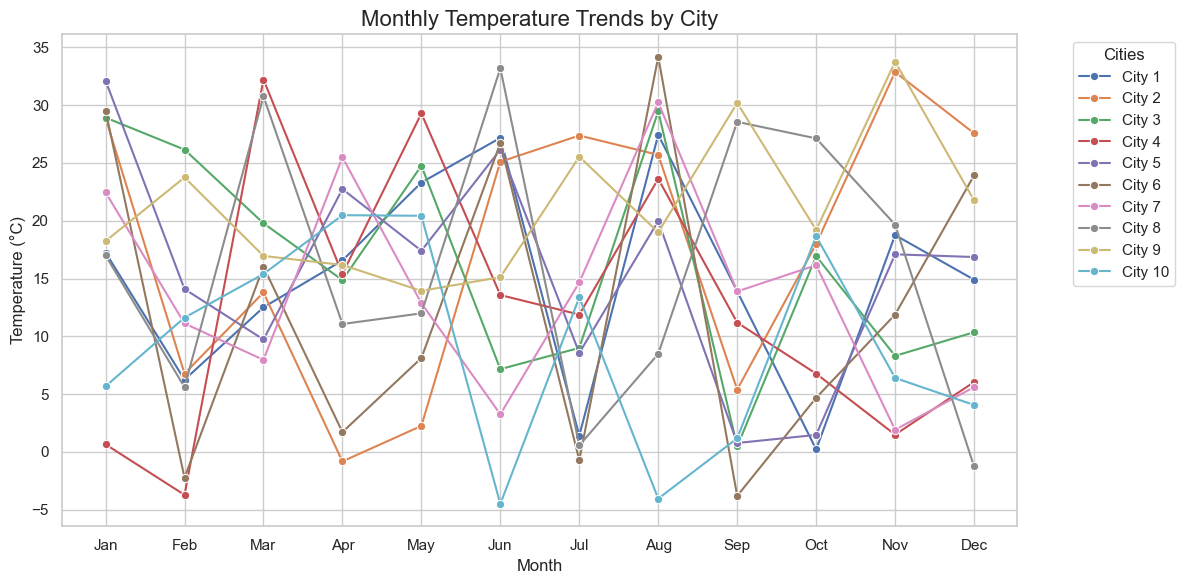

In [26]:
# 3. Data Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert df_temps to long-form (Tidy Data)
# 'id_vars' is what stays as a column, 'var_name' is the new Month column
df_long = df_temps.reset_index().rename(columns={'index': 'City'}).melt(
    id_vars='City', 
    var_name='Month', 
    value_name='Temperature'
)

# 2. Plotting with Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# hue='City' tells Seaborn to give each city its own color
sns.lineplot(data=df_long, x='Month', y='Temperature', hue='City', marker='o')

# 3. Formatting
plt.title('Monthly Temperature Trends by City', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.legend(title='Cities', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()

plt.show()

Summary Report:

City with Highest Average Temperature: City 9 (21.14°C)

City with Lowest Average Temperature: City 10 (9.07°C)

Because the temperature data here is randomly generated, we do not see trends we would expect to see in real world data. In real world temperature data, we would expect to see gradual increases and decreases in monthly temperatures in accordance with seasons. We would also expect to see cities with monthly temperatures that fit within a general range fitting their climates. Looking at the line chart we can see that the data is instead fully random within the range specified, without those real world trends.